# import modules

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from functions import *
plt.rcParams["font.size"] = 14
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",
})

# averaged constant fitting

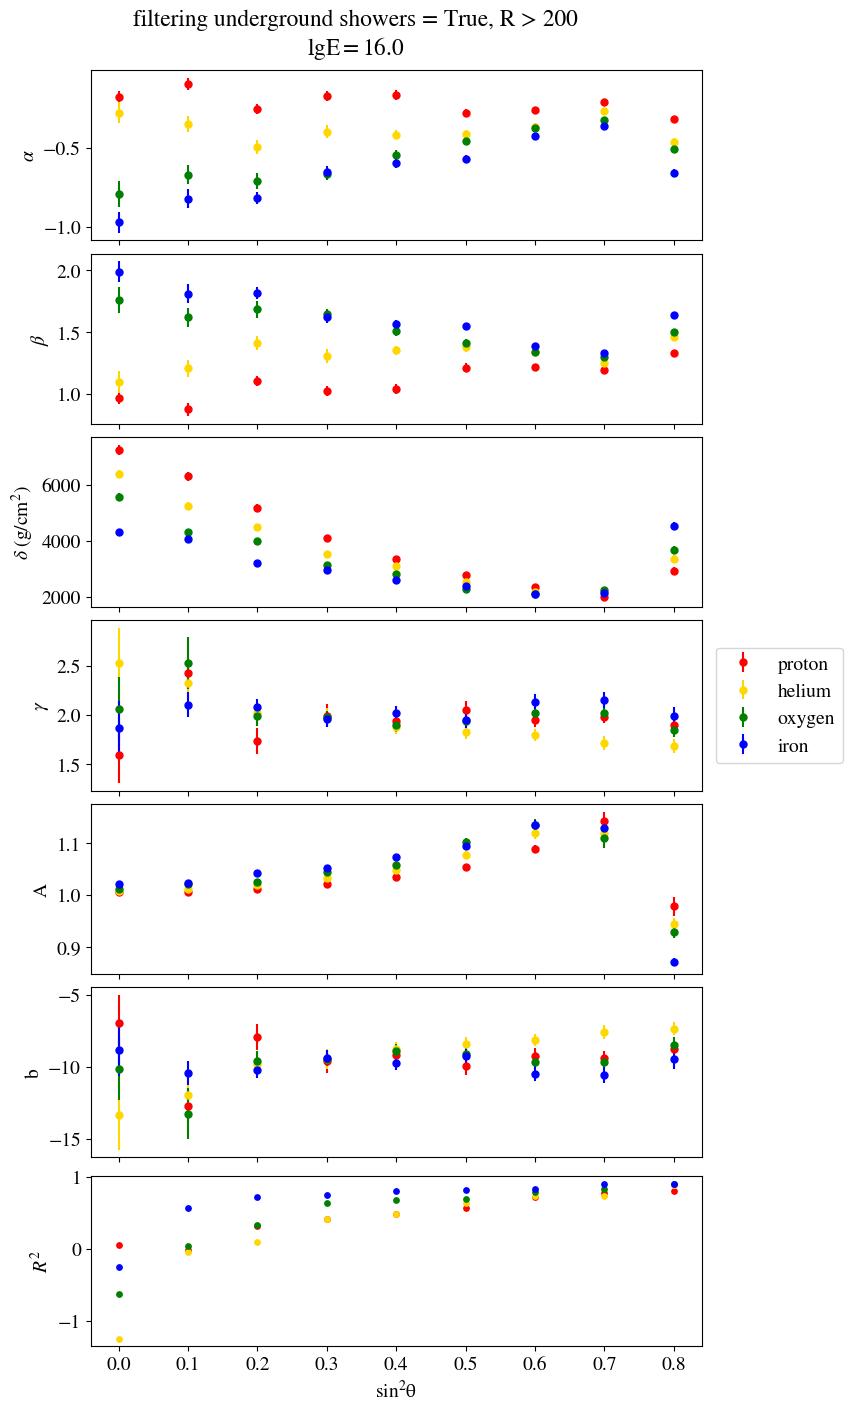

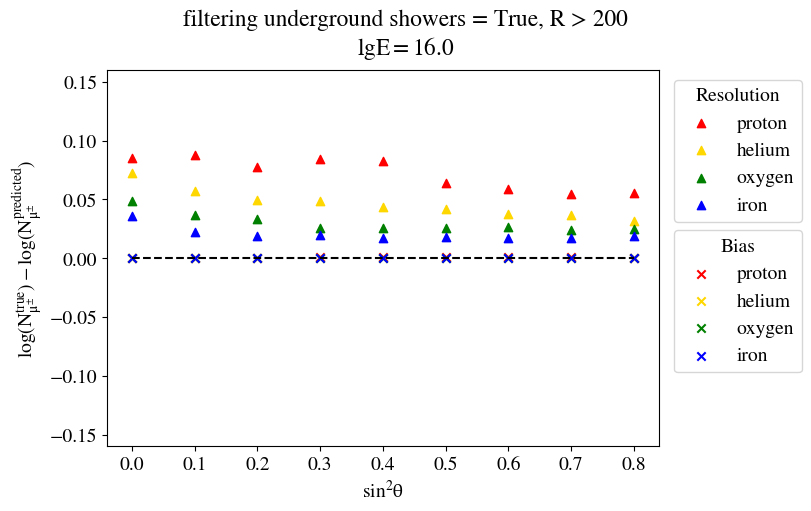

In [2]:
ThreshR = 200 # minimum radius boundary 
filteringXmax = True # condition of underground Xmax, True if filtered
energy_all = False
NmuNorm = False
lgE_GeV_bin = 16.0
RegressionFixedEnergyBin(ThreshR, filteringXmax, energy_all, lgE_GeV_bin, NmuNorm)

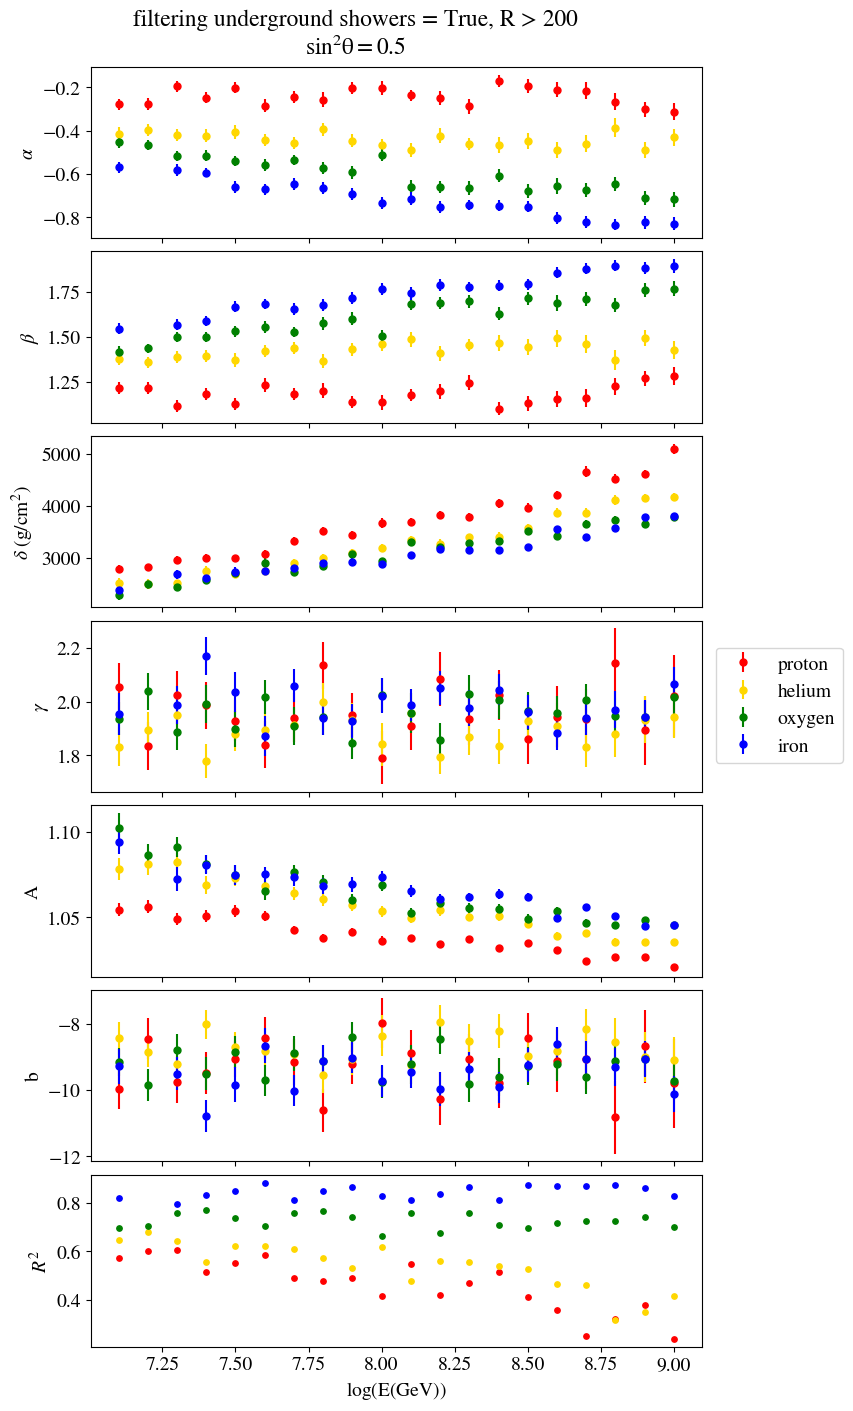

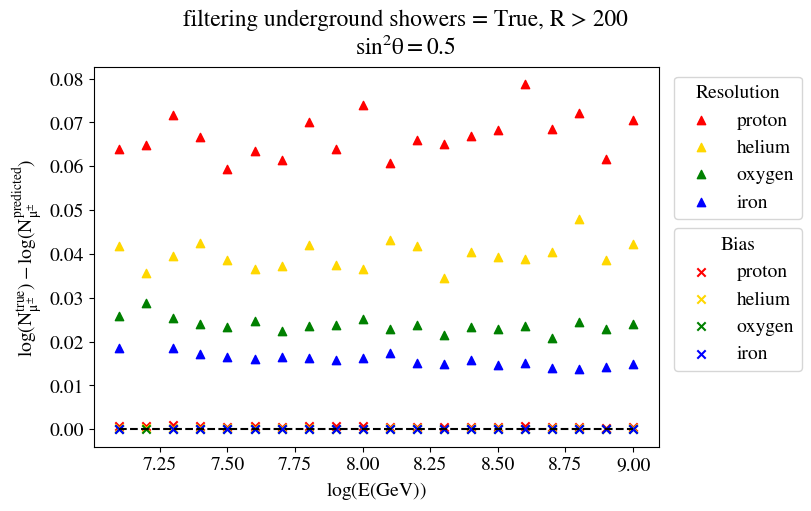

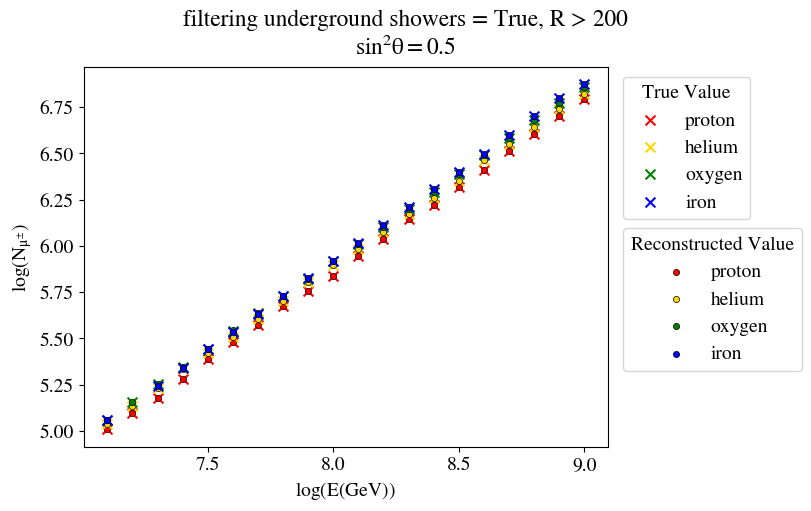

In [2]:
ThreshR = 200
filteringXmax = True 
zenith_all = False
NmuNorm = False
sin2_bin = 0.5
RegressionFixedZenithBin(ThreshR, filteringXmax, zenith_all, sin2_bin, NmuNorm)


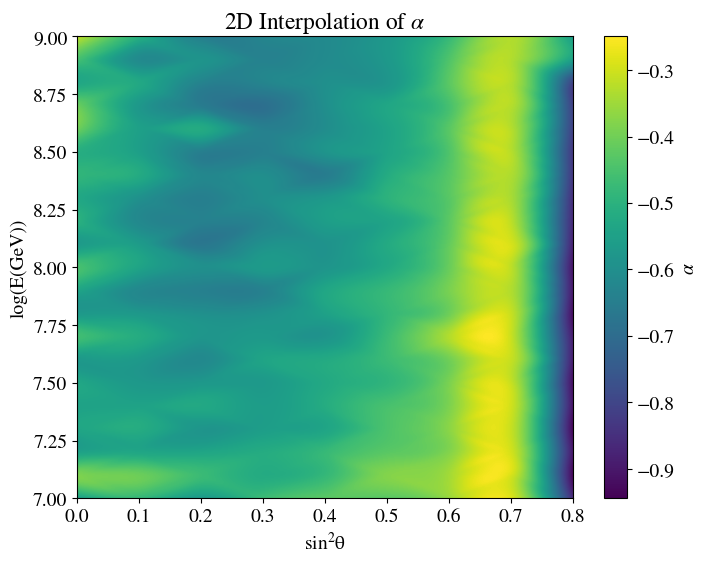

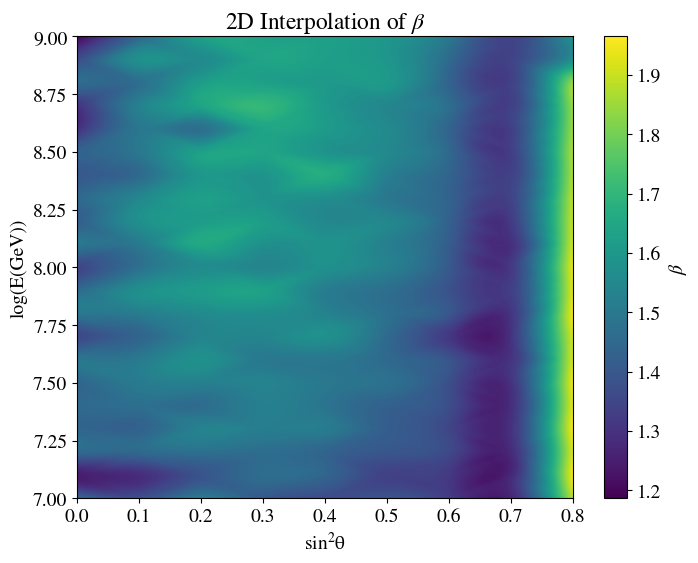

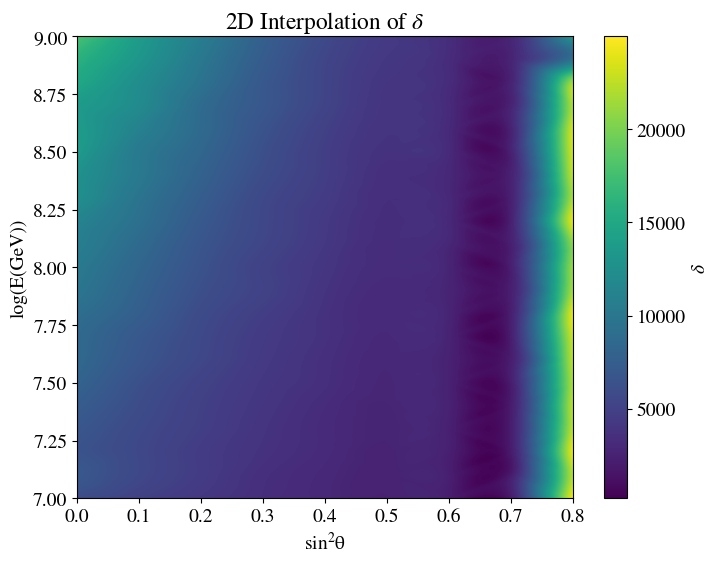

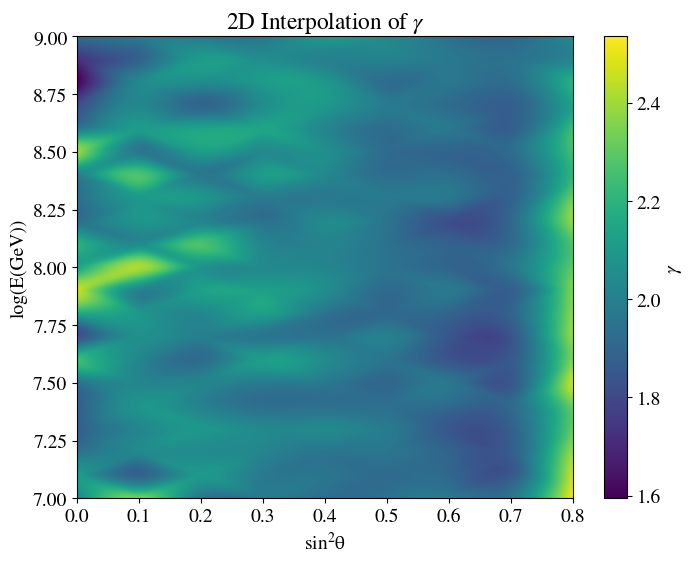

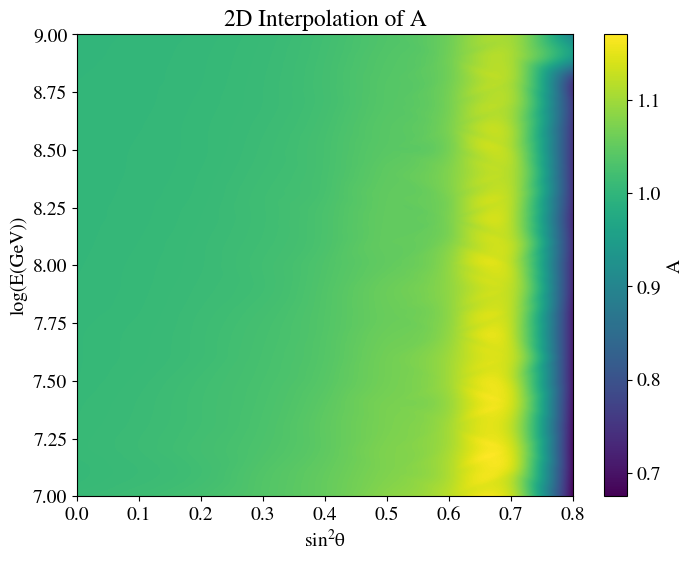

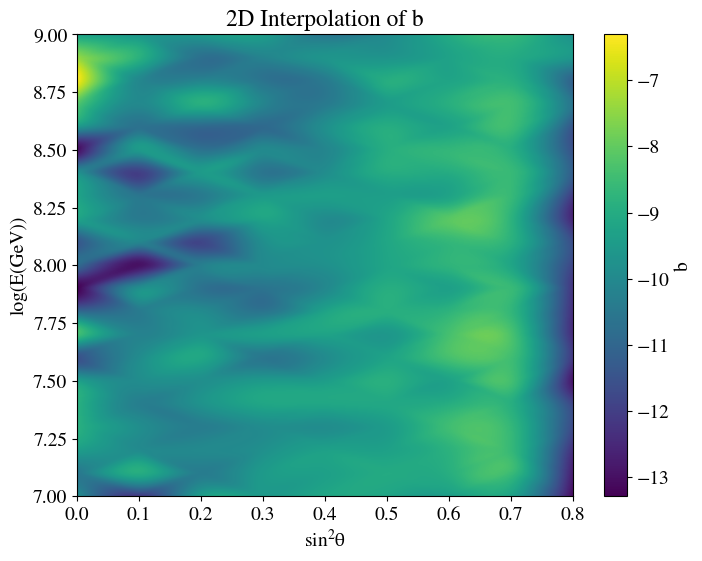

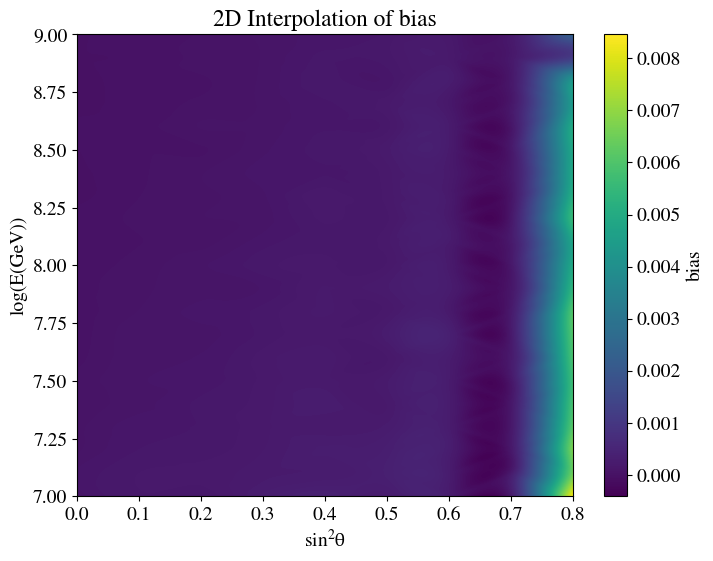

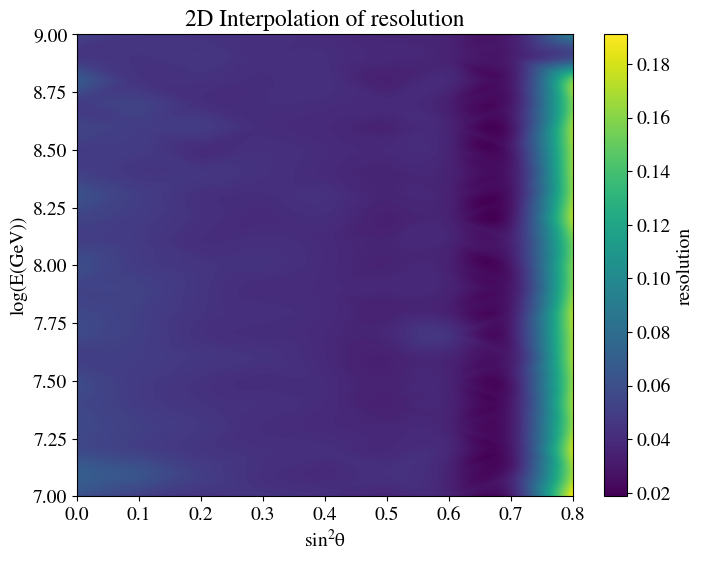

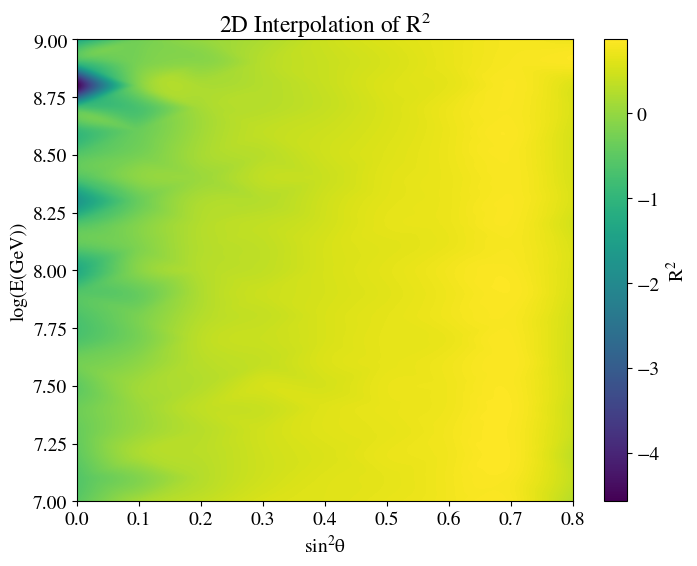

Text(0, 0.5, '$\\mathrm{log(N_{\\mu^{\\pm}})}$')

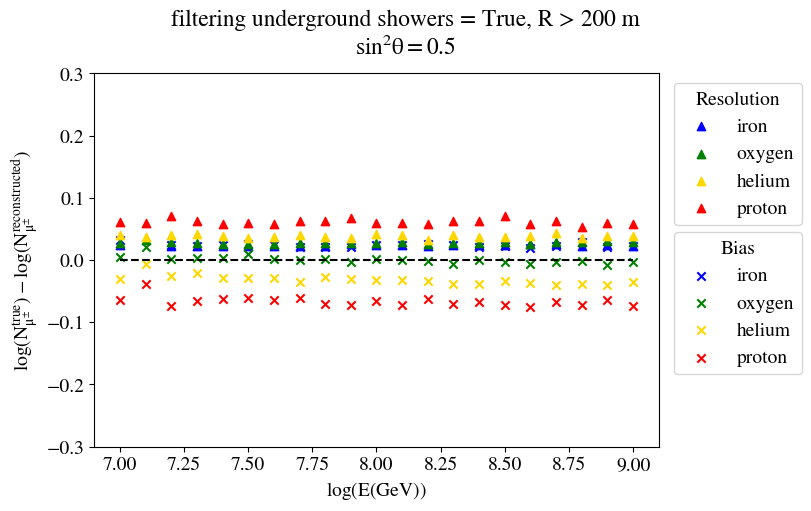

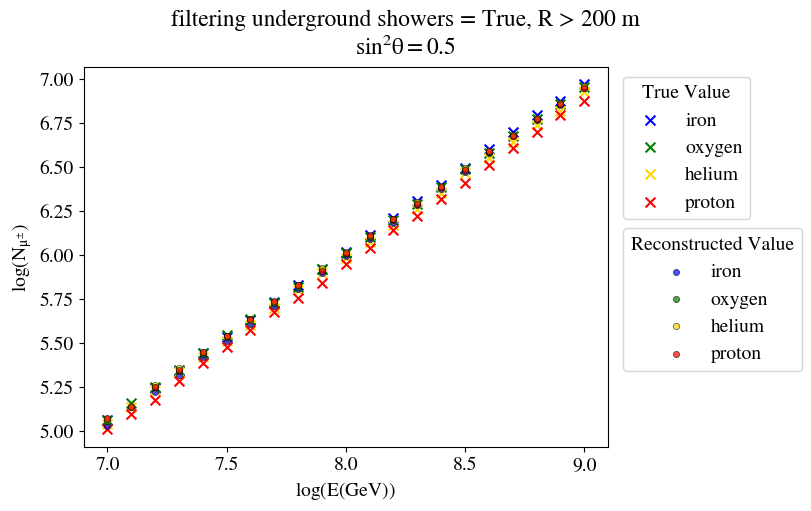

In [ ]:
ThreshR = 200
filteringXmax = True 
NmuNorm = False
df_params, df_Nmu = GetConstFromRegression(ThreshR, filteringXmax, NmuNorm)

# input lgE and sin2 
primEnergy = 1e7		 # primary energy in GeV should vary between 1e7 and 1e9 GeV
sin2 = 0.0 			# sin2 should vary between 0.0 and 0.8
Edep = 6			# Edep in GeV should vary between 3 and 16000 GeV 
Erad = 8e-6 				# Erad in GeV should vary between 1.5e-6 and 6 GeV 
Xmax = 622				# Xmax in g/cm^2 should vary between 450 and 1200 g/cm^2 
plotting = True 
printing = False
const_interp(df_params, primEnergy, sin2, Edep, Erad,Xmax, plotting, printing)

sin2 = 0.5

energy_bins = np.linspace(7.0, 9.0, 21)
sin2theta = df_Nmu['sin2theta']
energy = df_Nmu['energy']
particle = df_Nmu['particle']

fig, ax = plt.subplots(figsize=(8,5), constrained_layout=True)
fig2, ax2 = plt.subplots(figsize=(8,5), constrained_layout=True)

handle_bias = []
handle_res = []
handle_true = []
handle_recon = []
# colors = ['red','gold', 'green', 'blue']
# particle_bins = ['proton', 'helium', 'oxygen', 'iron']
particle_bins = ['iron', 'oxygen', 'helium', 'proton']
colors = ['blue', 'green', 'gold', 'red']
titlelabel =  f'removing underground Xmax = {filteringXmax}, R > {ThreshR} m'
zenith_label = rf'$\mathrm{{sin^2 \theta = {sin2}}}$'

for p_idx, p in enumerate(particle_bins):

	Nmu_true_all = []
	Nmu_pred_all = []
	bias_all = []
	reso_all = []
	energy_all = []

	for e_idx, e in enumerate(energy_bins):

		mask = np.isclose(sin2theta, sin2) & (energy == e) & (particle == p)
		df_mask = df_Nmu[mask]

		Nmu_true = df_mask['Nmu_true'].values
		Nmu_pred = df_mask['Nmu_pred'].values
		bias = df_mask['bias'].values
		reso = df_mask['reso'].values
		
		if not df_mask.empty:
			Nmu_true_all.append(Nmu_true)
			Nmu_pred_all.append(Nmu_pred)
			bias_all.append(bias)
			reso_all.append(reso)
			energy_all.append(e)

	bias = ax.scatter(energy_all, bias_all, color = colors[p_idx], marker = 'x', label = p )
	res = ax.scatter(energy_all, reso_all, color = colors[p_idx], marker = '^', label = p)
	
	true = ax2.scatter(energy_all, Nmu_true_all, color = colors[p_idx], marker = 'x', label = p, s = 50, zorder = 2)
	recon = ax2.scatter(energy_all, Nmu_pred_all, color = colors[p_idx], marker = 'o', label = p, s = 20, zorder = 3,
					edgecolors = 'black', linewidths=0.5, alpha = 0.7)

	handle_res.append(res)
	handle_bias.append(bias)
	handle_true.append(true)
	handle_recon.append(recon)

fig.suptitle(titlelabel + '\n' + zenith_label)
leg1 = ax.legend(bbox_to_anchor=(1.01, 1), handles= handle_res, loc='upper left', title="Resolution")
ax.add_artist(leg1) 
ax.legend(bbox_to_anchor=(1.01, 0.6), handles=handle_bias, loc='upper left', title="Bias")
ax.set_xlabel(rf'$\mathrm{{log(E (GeV))}}$')
ax.set_ylabel(rf'$\mathrm{{log(N_{{\mu^{{\pm}}}}^{{true}}) - log(N_{{\mu^{{\pm}}}}^{{reconstructed}})}}$')
ax.set_title(f'')
ax.set_ylim(-0.3,0.3)
ax.hlines(y= 0, xmin = min(energy_all), xmax= max(energy_all), colors = 'k', linestyles =  '--')

fig2.suptitle(titlelabel + '\n' + zenith_label)
leg2 = ax2.legend(bbox_to_anchor=(1.01, 1), handles= handle_true, loc='upper left', title="True Value")
ax2.add_artist(leg2) 
ax2.legend(bbox_to_anchor=(1.01, 0.6), handles=handle_recon, loc='upper left', title="Reconstructed Value")
ax2.set_xlabel(rf'$\mathrm{{log(E (GeV))}}$')
ax2.set_ylabel(rf'$\mathrm{{log(N_{{\mu^{{\pm}}}})}}$')

# Fitting across primaries

Text(0, 0.5, '$\\mathrm{log(N_{\\mu^{\\pm}})}$')

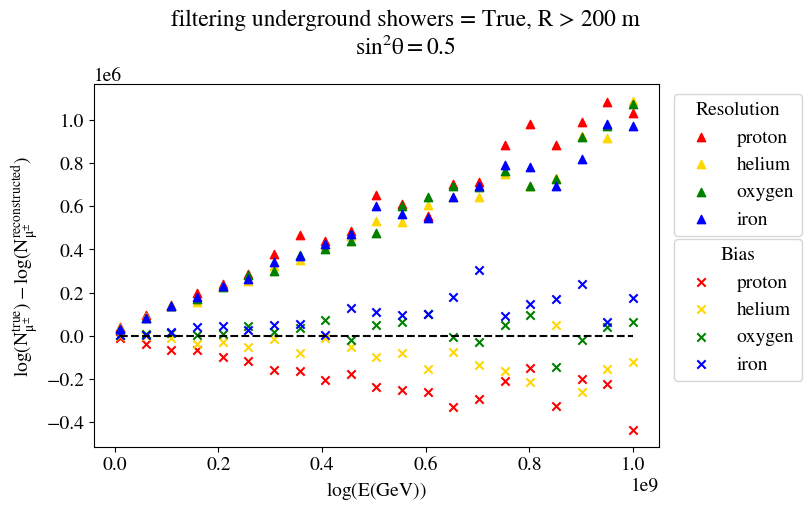

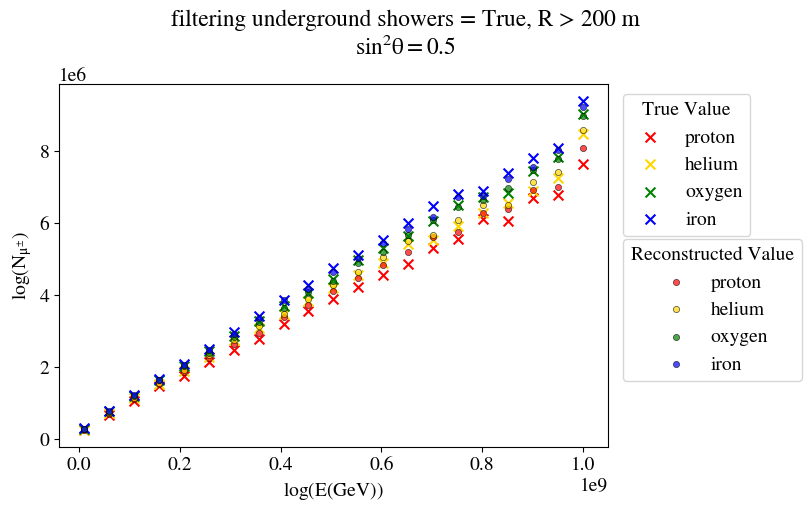

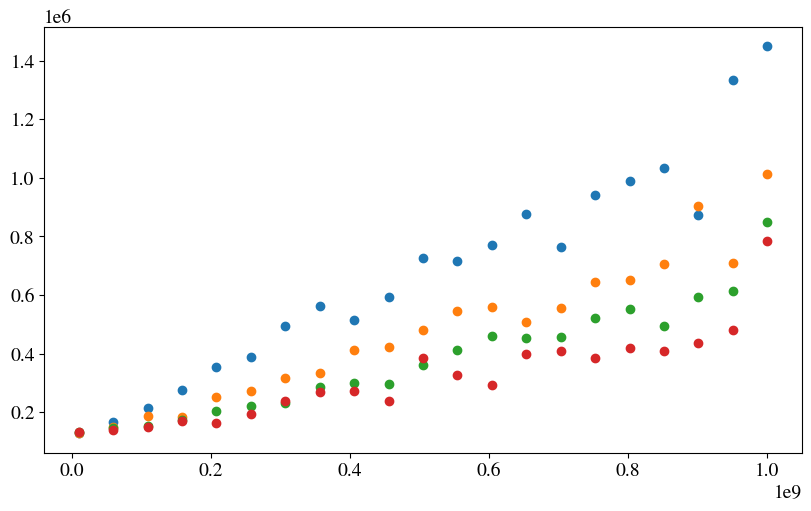

In [ ]:

ThreshR = 200
filteringXmax = True 
NmuNorm = False
df_params, df_Nmu = GetConstFromRegression2(ThreshR, filteringXmax, NmuNorm)

# input lgE and sin2 
primEnergy = 1e7		# primary energy in GeV should vary between 1e7 and 1e9 GeV
sin2 = 0.5				# sin2 should vary between 0.0 and 0.8
Edep = 6				# Edep in GeV should vary between 3 and 16000 GeV 
Erad = 8e-6 			# Erad in GeV should vary between 1.5e-6 and 6 GeV 
Xmax = 622				# Xmax in g/cm^2 should vary between 450 and 1200 g/cm^2 
plotting = False 
printing = False
const_interp(df_params, primEnergy, sin2, Edep, Erad,Xmax, plotting, printing)

# energy_bins = np.linspace(7.0, 9.0, 21)
energy_bins = np.linspace(10**7, 10**9.0, 21)
sin2theta = df_Nmu['sin2theta']
energy = df_Nmu['energy']
particle = df_Nmu['particle']

fig, ax = plt.subplots(figsize=(8,5), constrained_layout=True)
fig2, ax2 = plt.subplots(figsize=(8,5), constrained_layout=True)
fig3, ax3 = plt.subplots(figsize =(8,5), constrained_layout = True)

handle_bias = []
handle_res = []
handle_true = []
handle_recon = []
colors = {'proton': 'red',
			'helium': 'gold',
			'oxygen': 'green',
			'iron': 'blue'}
particle_bins = ['proton', 'helium', 'oxygen', 'iron']

titlelabel =  f'removing underground Xmax = {filteringXmax}, R > {ThreshR} m'
zenith_label = rf'$\mathrm{{sin^2 \theta = {sin2}}}$'

for p_idx, p in enumerate(particle_bins):

	Nmu_true_all = []
	Nmu_pred_all = []
	SD_Nmu_true_all = []
	bias_all = []
	reso_all = []
	energy_all = []

	for e_idx, e in enumerate(energy_bins):

		mask = np.isclose(sin2theta, sin2) & (energy == e) & (particle == p)
		df_mask = df_Nmu[mask]
		Nmu_true = df_mask['Nmu_true'].values
		Nmu_pred = df_mask['Nmu_pred'].values
		SD_Nmu_true = df_mask['SD_Nmu_true'].values
		bias = df_mask['bias'].values
		reso = df_mask['reso'].values
		
		if not df_mask.empty:
			Nmu_true_all.append(Nmu_true)
			Nmu_pred_all.append(Nmu_pred)
			SD_Nmu_true_all.append(SD_Nmu_true)
			bias_all.append(bias)
			reso_all.append(reso)
			energy_all.append(e)

	bias = ax.scatter(energy_all, bias_all, color = colors[p], marker = 'x', label = p )
	res = ax.scatter(energy_all, reso_all, color = colors[p], marker = '^', label = p)
	
	true = ax2.scatter(energy_all, Nmu_true_all, color = colors[p], marker = 'x', label = p, s = 50, zorder = 2)
	recon = ax2.scatter(energy_all, Nmu_pred_all, color = colors[p], marker = 'o', label = p, s = 20, zorder = 3,
					edgecolors = 'black', linewidths=0.5, alpha = 0.7)

	SD_true = ax3.scatter(energy_all, SD_Nmu_true_all)

	handle_res.append(res)
	handle_bias.append(bias)
	handle_true.append(true)
	handle_recon.append(recon)

fig.suptitle(titlelabel + '\n' + zenith_label)
leg1 = ax.legend(bbox_to_anchor=(1.01, 1), handles= handle_res, loc='upper left', title="Resolution")
ax.add_artist(leg1) 
ax.legend(bbox_to_anchor=(1.01, 0.6), handles=handle_bias, loc='upper left', title="Bias")
ax.set_xlabel(rf'$\mathrm{{log(E (GeV))}}$')
ax.set_ylabel(rf'$\mathrm{{log(N_{{\mu^{{\pm}}}}^{{true}}) - log(N_{{\mu^{{\pm}}}}^{{reconstructed}})}}$')
ax.set_title(f'')
# ax.set_ylim(-0.3,0.3)
ax.hlines(y= 0, xmin = min(energy_all), xmax= max(energy_all), colors = 'k', linestyles =  '--')

fig2.suptitle(titlelabel + '\n' + zenith_label)
leg2 = ax2.legend(bbox_to_anchor=(1.01, 1), handles= handle_true, loc='upper left', title="True Value")
ax2.add_artist(leg2) 
ax2.legend(bbox_to_anchor=(1.01, 0.6), handles=handle_recon, loc='upper left', title="Reconstructed Value")
ax2.set_xlabel(rf'$\mathrm{{log(E (GeV))}}$')
ax2.set_ylabel(rf'$\mathrm{{log(N_{{\mu^{{\pm}}}})}}$')

In [3]:
energy_bins = np.linspace(10**7, 10**9.0, 21)
print(energy_bins)

[1.000e+07 5.950e+07 1.090e+08 1.585e+08 2.080e+08 2.575e+08 3.070e+08
 3.565e+08 4.060e+08 4.555e+08 5.050e+08 5.545e+08 6.040e+08 6.535e+08
 7.030e+08 7.525e+08 8.020e+08 8.515e+08 9.010e+08 9.505e+08 1.000e+09]


In [3]:
ThreshR = 200
filteringXmax = True
NmuNorm = False
df = pd.read_parquet(f'RandomForestRegression/data_for_regression_{ThreshR}_Xmax_{filteringXmax}_NmuNorm_{NmuNorm}.parquet')

In [6]:
print(df_params)

     sin2theta        energy     alpha      beta       delta     gamma  \
0          0.0  1.000000e+07 -0.000314  0.058878  460.124359  0.007763   
1          0.1  1.000000e+07 -0.000454  0.075149  393.289842  0.007753   
2          0.2  1.000000e+07 -0.000678  0.098781  340.267435  0.007759   
3          0.3  1.000000e+07 -0.000982  0.131793  289.589666  0.008577   
4          0.4  1.000000e+07 -0.001713  0.187707  256.322891  0.009378   
..         ...           ...       ...       ...         ...       ...   
184        0.4  1.000000e+09 -0.000661  0.161737  329.444723  0.296156   
185        0.5  1.000000e+09 -0.001424  0.256318  265.683386  0.348115   
186        0.6  1.000000e+09 -0.003447  0.421785  204.841910  0.383091   
187        0.7  1.000000e+09 -0.013664  0.752906  172.388945  0.420449   
188        0.8  1.000000e+09 -0.254834  1.906967  174.478707  0.538343   

            A             b        R2           bias          reso  
0    1.090506 -5.501376e+04  0.500679     

In [4]:
print(df_Nmu)

    particle  sin2theta        energy      Nmu_true      Nmu_pred  \
0     proton        0.0  1.000000e+07  2.930172e+05  2.943752e+05   
1     helium        0.0  1.000000e+07  3.214170e+05  3.162226e+05   
2     oxygen        0.0  1.000000e+07  3.596185e+05  3.554591e+05   
3       iron        0.0  1.000000e+07  3.976915e+05  4.095585e+05   
4     proton        0.1  1.000000e+07  2.962334e+05  2.994019e+05   
..       ...        ...           ...           ...           ...   
746     iron        0.7  1.000000e+09  6.172640e+06  5.855204e+06   
747   proton        0.8  1.000000e+09  2.400272e+06  3.487545e+06   
748   helium        0.8  1.000000e+09  3.544586e+06  3.265929e+06   
749   oxygen        0.8  1.000000e+09  3.833575e+06  3.225724e+06   
750     iron        0.8  1.000000e+09  2.887044e+06  3.924490e+06   

      SD_Nmu_true          bias          reso  
0    1.466610e+05 -1.358072e+03  7.924257e+04  
1    1.520839e+05  5.194365e+03  1.237535e+05  
2    1.657514e+05  4.159333